## Configs

Check if the module `torch.geometric` is installed

In [1]:
import sys
import subprocess

try:
    import torch_geometric
except ImportError:
    print("torch_geometric not found. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch_geometric"])
    print("Installation complete!")

torch_geometric not found. Installing now...
Installation complete!


Load modules

In [23]:
import os
from google.colab import drive

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

import torch
import torch_geometric
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

Check if the drive is mounted:

In [3]:
# Set drive path
drive_path = '/content/drive'

# Mount drive
if not os.path.exists(drive_path):
    print("Mounting Google Drive...")
    drive.mount(drive_path)
else:
    print("Google Drive is already mounted.")

Mounting Google Drive...
Mounted at /content/drive


Set the paths:

In [4]:
# Project path
path_root = "/content/drive/MyDrive/Deep Learning/final_coursework/"

# Change the working directory
os.chdir(path_root)

Load my own modules:

In [5]:
from src.data_preprocessing import get_cached_dataset, prep_sklearn_data, prepare_splits, apply_gene_filter
from src.dimensionality_reduction import reduce_dimensionality_hvg
from src.plots import scatter_plot, plot_losses
from src.models_architecture import OriginalMLPRegressor, NormalizerMLPRegressor, SkipConnMLPRegressor, UltimateMLPRegressor
from src.models_training import CustomVarianceLoss, GeneDataset, train_pytorch_model
from src.models_evaluation import evaluate_baseline_model, evaluate_pytorch_model

## Data

Load the data sets

In [6]:
PC3 = get_cached_dataset(cell_line='PC3', path_root='data/')
A549 = get_cached_dataset(cell_line='A549', path_root='data/')

Define the dataset to work with:

In [7]:
dataset = PC3

## Baseline model

Let's reduce the number of relevant genes in order to simplify the calculations:

In [8]:
# Top n genes with the highest variance between the diseased and the treated states
n_base = 1000

# Get the lighter dataset and the corresponding indexes
baseline_dataset, baseline_kept_indices = reduce_dimensionality_hvg(dataset, top_k=n_base)

Train-test splitting:

In [9]:
# Generate indexes
train_idx_dict, val_idx_dict, test_idx = prepare_splits(
    dataset=baseline_dataset,
    val_size=0.1,
    test_size=0.1,
    splitting_scheme="random",
    N_folds=1,
    seed=42
)

# Split data into train and test sets
train_samples = [baseline_dataset[i] for i in train_idx_dict[0]]
val_samples = [baseline_dataset[i] for i in val_idx_dict[0]]
test_samples = [baseline_dataset[i] for i in test_idx]

Preparing data for `scikit-learn`

In [10]:
X_train, Y_train = prep_sklearn_data(train_samples)
X_test, Y_test = prep_sklearn_data(test_samples)

The most basic model is linear regression, predicting the intervened state given the diseased state and the perturbed genes.

In [11]:
# Instantiate and fit a ridge regression model
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train, Y_train)

Ridge(alpha=1)

Baseline model's evaluation metrics:

In [12]:
# Predict results in the test set
Y_pred = ridge_model.predict(X_test)

# Compute metrics
mse, r2_scores, gene_var_scores = evaluate_baseline_model(model=ridge_model,
                        X_test=X_test,
                        Y_test= Y_test)

print("-" * 30)
print(f"Baseline Ridge MSE: {mse:.5f}")
print(f"Baseline Ridge Mean R^2 per sample: {np.mean(r2_scores):.5f}")
print(f"Baseline Ridge Mean Gene Var Score: {np.mean(gene_var_scores):.5f}")
print("-" * 30)

------------------------------
Baseline Ridge MSE: 0.06545
Baseline Ridge Mean R^2 per sample: 0.79879
Baseline Ridge Mean Gene Var Score: 0.09564
------------------------------


Evaluating the std deviation per gene (predicted vs real):

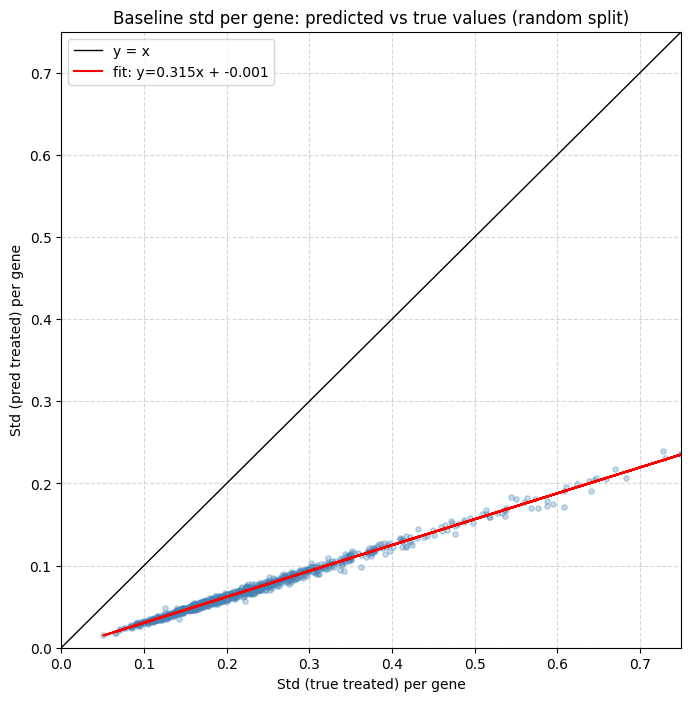

In [13]:
# Compute standard deviation
std_true = np.std(Y_test, axis=0)
std_pred = np.std(Y_pred, axis=0)

# Scatter plot
scatter_plot(x=std_true, y=std_pred,
            title="Baseline std per gene: predicted vs true values (random split)",
            xlabel="Std (true treated) per gene",
            ylabel="Std (pred treated) per gene")

## MLP

Dimensionality reduction:

In [14]:
# Top n genes with the highest variance between the diseased and the treated states
n = 3000

# Get the lighter datasets and the corresponding indexes
reduced_dataset, kept_indices = reduce_dimensionality_hvg(dataset, top_k=n)

### Data preprocessing

In [15]:
# Generate indices
train_idx_dict, val_idx_dict, test_idx = prepare_splits(
    dataset=dataset,
    val_size=0.1,
    test_size=0.1,
    splitting_scheme="random",
    N_folds=1,
    seed=42
)

# Split data into train and test sets
train_samples = [reduced_dataset[i] for i in train_idx_dict[0]]
val_samples = [reduced_dataset[i] for i in val_idx_dict[0]]
test_samples = [reduced_dataset[i] for i in test_idx]

# DataLoaders configuration
batch_size = 64
train_loader = DataLoader(GeneDataset(train_samples),
                        batch_size=batch_size, shuffle=True)
val_loader = DataLoader(GeneDataset(val_samples),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(GeneDataset(test_samples),
                        batch_size=batch_size, shuffle=False)

### Train phase

In [16]:
# --- Training configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training in: {device}")

n_epochs = 150

model = UltimateMLPRegressor(d=n).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# --- Training loop ---
skipconn_MLP, losses = train_pytorch_model(model=model,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    criterion=criterion,
                    optimizer=optimizer,
                    device=device,
                    epochs=n_epochs)

Training in: cuda
Starting training on cuda...
Epoch 01/150 | Train Loss: 0.2643 | Val Loss: 0.1352
Epoch 02/150 | Train Loss: 0.1669 | Val Loss: 0.0960
Epoch 03/150 | Train Loss: 0.1404 | Val Loss: 0.0862
Epoch 04/150 | Train Loss: 0.1296 | Val Loss: 0.0821
Epoch 05/150 | Train Loss: 0.1227 | Val Loss: 0.0793
Epoch 06/150 | Train Loss: 0.1178 | Val Loss: 0.0776
Epoch 07/150 | Train Loss: 0.1137 | Val Loss: 0.0761
Epoch 08/150 | Train Loss: 0.1096 | Val Loss: 0.0754
Epoch 09/150 | Train Loss: 0.1065 | Val Loss: 0.0750
Epoch 10/150 | Train Loss: 0.1032 | Val Loss: 0.0735
Epoch 11/150 | Train Loss: 0.1001 | Val Loss: 0.0729
Epoch 12/150 | Train Loss: 0.0970 | Val Loss: 0.0722
Epoch 13/150 | Train Loss: 0.0944 | Val Loss: 0.0713
Epoch 14/150 | Train Loss: 0.0922 | Val Loss: 0.0700
Epoch 15/150 | Train Loss: 0.0895 | Val Loss: 0.0689
Epoch 16/150 | Train Loss: 0.0872 | Val Loss: 0.0688
Epoch 17/150 | Train Loss: 0.0852 | Val Loss: 0.0678
Epoch 18/150 | Train Loss: 0.0834 | Val Loss: 0.0681

### Evaluation phase

Train vs test loss:

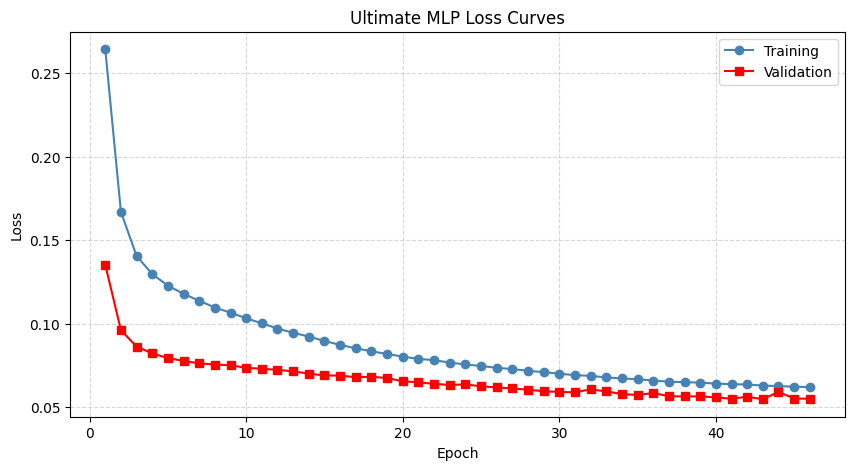

In [17]:
plot_losses(losses=losses,
            title="Ultimate MLP Loss Curves",
            xlabel="Epoch", ylabel="Loss")

Compute metrics:

In [18]:
# Compute metrics
mse, r2_scores, gene_var_scores, Y_true_dl, Y_pred_dl = evaluate_pytorch_model(model=model,
                    test_loader=test_loader,
                    device=device)

# Display results
print("-" * 30)
print(f"Ultimate MLP MSE: {mse:.5f}")
print(f"Ultimate MLP Mean R^2 per sample: {np.mean(r2_scores):.5f}")
print(f"Ultimate MLP Mean Gene Var Score: {np.mean(gene_var_scores):.5f}")
print("-" * 30)

------------------------------
Ultimate MLP MSE: 0.05489
Ultimate MLP Mean R^2 per sample: 0.77206
Ultimate MLP Mean Gene Var Score: 0.68494
------------------------------


Per gene std scatter plot:

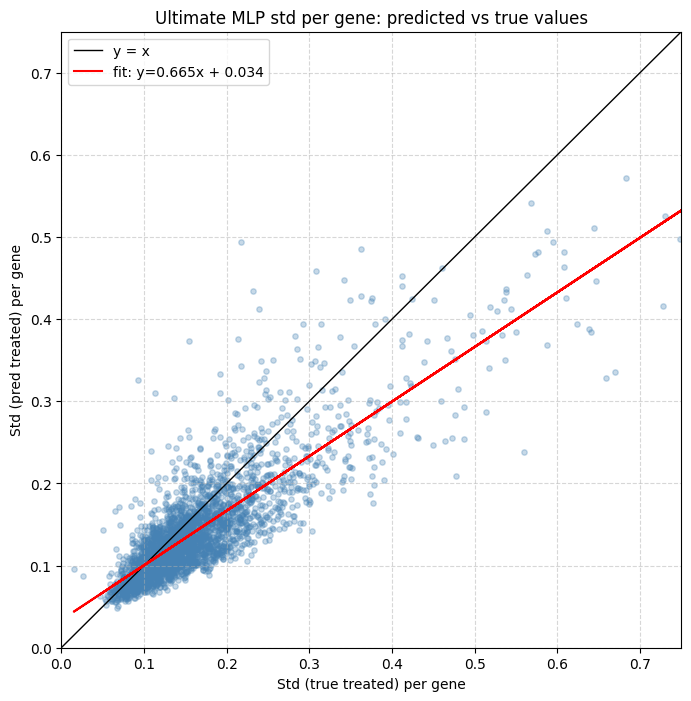

In [19]:
# Compute standard deviation
std_true = np.std(Y_true_dl, axis=0)
std_pred_dl = np.std(Y_pred_dl, axis=0)

# Display scatter plot
scatter_plot(x=std_true, y=std_pred_dl,
                    title="Ultimate MLP std per gene: predicted vs true values",
                    xlabel="Std (true treated) per gene",
                    ylabel="Std (pred treated) per gene")

## Final model

Now that we have the optimal model, let's train it using the A549 line cell and test it using the PC3 line cell.

In [20]:
# Concatenate HT29 and A549 cell lines lists
dataset_train = A549

Now, let's reduce dimensionality:

In [22]:
# Select top genes with the highest variance in the training set
n_final = 3000
train_dataset_reduced, kept_indices_final = reduce_dimensionality_hvg(dataset_train, top_k=n_final)

# Apply the exact same gene filter to the test set
test_dataset_reduced = apply_gene_filter(PC3, kept_indices_final)


Now we need a validation set to asess the early stopping during the model's training:

In [24]:
# Generate indices
train_samples, val_samples = train_test_split(
    train_dataset_reduced,
    test_size=0.1,
    random_state=42
)

test_samples = test_dataset_reduced

# Create data loaders
batch_size = 64
train_loader = DataLoader(GeneDataset(train_samples), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(GeneDataset(val_samples), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(GeneDataset(test_samples), batch_size=batch_size, shuffle=False)

Now let's train the model:

In [26]:
# --- Training configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training in: {device}")
model_cross = SkipConnMLPRegressor(d=n_final).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_cross.parameters(), lr=1e-5)

# Entrenamos
trained_model_cross, history_cross = train_pytorch_model(
    model=model_cross,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=150,
    patience=3
)

Training in: cuda
Starting training on cuda...
Epoch 01/150 | Train Loss: 0.1143 | Val Loss: 0.1006
Epoch 02/150 | Train Loss: 0.0962 | Val Loss: 0.0901
Epoch 03/150 | Train Loss: 0.0904 | Val Loss: 0.0875
Epoch 04/150 | Train Loss: 0.0883 | Val Loss: 0.0854
Epoch 05/150 | Train Loss: 0.0857 | Val Loss: 0.0823
Epoch 06/150 | Train Loss: 0.0832 | Val Loss: 0.0804
Epoch 07/150 | Train Loss: 0.0815 | Val Loss: 0.0791
Epoch 08/150 | Train Loss: 0.0802 | Val Loss: 0.0775
Epoch 09/150 | Train Loss: 0.0791 | Val Loss: 0.0766
Epoch 10/150 | Train Loss: 0.0781 | Val Loss: 0.0756
Epoch 11/150 | Train Loss: 0.0774 | Val Loss: 0.0752
Epoch 12/150 | Train Loss: 0.0768 | Val Loss: 0.0750
Epoch 13/150 | Train Loss: 0.0764 | Val Loss: 0.0742
Epoch 14/150 | Train Loss: 0.0760 | Val Loss: 0.0738
Epoch 15/150 | Train Loss: 0.0757 | Val Loss: 0.0737
Epoch 16/150 | Train Loss: 0.0753 | Val Loss: 0.0733
Epoch 17/150 | Train Loss: 0.0750 | Val Loss: 0.0732
Epoch 18/150 | Train Loss: 0.0747 | Val Loss: 0.0727

Train vs test loss:

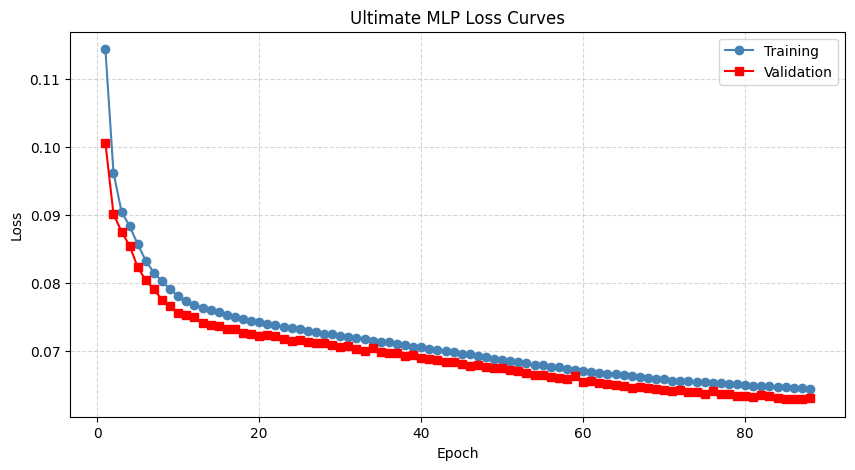

In [27]:
plot_losses(losses=history_cross,
            title="Ultimate MLP Loss Curves",
            xlabel="Epoch", ylabel="Loss")

Evaluate the model:

In [28]:
# Compute metrics
mse, r2_scores, gene_var_scores, Y_true_cross, Y_pred_cross = evaluate_pytorch_model(model=model_cross,
                    test_loader=test_loader,
                    device=device)

# Display results
print("-" * 30)
print(f"Ultimate MLP MSE: {mse:.5f}")
print(f"Ultimate MLP Mean R^2 per sample: {np.mean(r2_scores):.5f}")
print(f"Ultimate MLP Mean Gene Var Score: {np.mean(gene_var_scores):.5f}")
print("-" * 30)

------------------------------
Ultimate MLP MSE: 0.11743
Ultimate MLP Mean R^2 per sample: 0.63253
Ultimate MLP Mean Gene Var Score: 0.53222
------------------------------


Per gene std scatter plot:

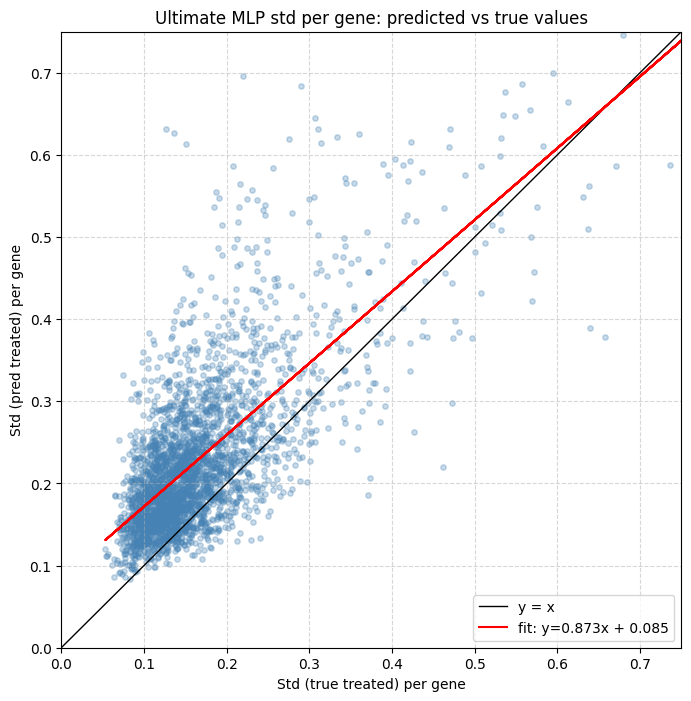

In [29]:
# Compute standard deviation
std_true = np.std(Y_true_cross, axis=0)
std_pred_cross = np.std(Y_pred_cross, axis=0)

# Display scatter plot
scatter_plot(x=std_true, y=std_pred_cross,
                    title="Ultimate MLP std per gene: predicted vs true values",
                    xlabel="Std (true treated) per gene",
                    ylabel="Std (pred treated) per gene")

## Conclusion

Even though the metrics aren't that good (the MSE is slightly higher in the model that crosses both cell lines and the R-squared is slightly lower), the ultimate model preserves the variance between the diseased and the intervened state.